# CMAPSS - Preprocessing, full fleet

Turns the four raw subsets into one training matrix: RUL labels, the sensors that
carry no information removed, per-regime standardisation, and the temporal
features that make this a time-series model rather than tabular regression on
time-indexed rows.

Three decisions are made here, and each is measured rather than assumed:

1. **Which sensors to drop.** Not the seven the FD001 pipeline hard-coded, but the
   ones with zero variance inside every operating regime.
2. **How to scale.** One scaler per regime, fitted on train only, because a
   sensor's level steps with the regime.
3. **What a row should know about its own past.** A 20-cycle rolling window per
   engine: level, volatility, and drift from that engine's own healthy baseline.

The last section compares the result against `preprocessing_full_fleet.pkl`, the
artifact the deployed model was trained with, so the agreement is demonstrated.

## 1. Imports and configuration

In [1]:
import sys
from pathlib import Path

# Add notebooks/utils to path (works on Mac, Windows, Linux)
_nb_root = Path('..').resolve()
if str(_nb_root) not in sys.path:
    sys.path.insert(0, str(_nb_root))

from utils.arkon_utils import save_figure

print('arkon_utils loaded')

arkon_utils loaded


In [2]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

ASSETS = 'timeseries'

print(f'python  {sys.version.split()[0]}')
print(f'pandas  {pd.__version__}')
print(f'numpy   {np.__version__}')
print(f'joblib  {joblib.__version__}')

python  3.12.10
pandas  2.3.3
numpy   2.4.4
joblib  1.5.3


## 2. Constants

`RUL_CAP` is the piecewise-linear RUL convention for CMAPSS: an engine with 300
cycles left is not meaningfully different from one with 200, because nothing in
the sensor trace has started to degrade yet. Capping the target at 125 stops the
model from spending capacity on that flat region. `WINDOW` is the length of the
rolling history each row is allowed to see.

In [3]:
COLUMNS = (['unit', 'cycle', 'os_1', 'os_2', 'os_3']
           + [f's{i}' for i in range(1, 22)])
SENSORS = [f's{i}' for i in range(1, 22)]
SUBSETS = ['FD001', 'FD002', 'FD003', 'FD004']

RAW_DIR = Path('../../data/01_cmapss/raw/CMaps')
PROC_DIR = Path('../../data/01_cmapss/processed')
PROC_DIR.mkdir(parents=True, exist_ok=True)

RUL_CAP = 125
WINDOW = 20

print(f'RUL capped at {RUL_CAP} cycles, rolling window {WINDOW} cycles')
print('raw :', RAW_DIR.resolve())
print('out :', PROC_DIR.resolve())

RUL capped at 125 cycles, rolling window 20 cycles
raw : D:\-PROJECTS\--Portfolio\arkon-manufacturing-ai\data\01_cmapss\raw\CMaps
out : D:\-PROJECTS\--Portfolio\arkon-manufacturing-ai\data\01_cmapss\processed


## 3. Load the fleet and attach the RUL

The two sets need different arithmetic. A training engine runs to failure, so its
RUL is simply the number of cycles left until its own last row. A test engine is
cut off before failure, and the life still left at that cut-off is what the
`RUL_*.txt` files hold, so the countdown starts from there.

The last row of each test engine is flagged. That row is the benchmark task: one
prediction per engine, at the moment a decision would actually be made.

**One trap, caught here by the assertion below.** The `RUL_*.txt` file is a bare
column of numbers, one per engine in unit order, with no key of its own.
Attaching it by position is correct only if the engines are also in unit order,
and grouping by the fleet-wide engine id is not: as text, `FD001_100` sorts
between `FD001_10` and `FD001_11`. The first version of this notebook did exactly
that, and every test label landed on the wrong engine. Nothing failed; the model
simply scored RMSE 59 instead of 11. The unit number is written onto the RUL file
and the two are merged on it, then the result is checked.

In [4]:
def read_subset(name, kind):
    frame = pd.read_csv(RAW_DIR / f'{kind}_{name}.txt', sep=r'\s+',
                        header=None, names=COLUMNS)
    frame['dataset'] = name
    frame['unit_uid'] = name + '_' + frame['unit'].astype(str)
    return frame


trains, tests = [], []
for name in SUBSETS:
    tr = read_subset(name, 'train')
    te = read_subset(name, 'test')
    rul = pd.read_csv(RAW_DIR / f'RUL_{name}.txt', header=None, names=['RUL'])

    # Train: RUL counts down from the engine's own last cycle
    last = tr.groupby('unit_uid').cycle.max().rename('max_cycle')
    tr = tr.merge(last, on='unit_uid')
    tr['RUL'] = (tr.max_cycle - tr.cycle).clip(upper=RUL_CAP)
    tr = tr.drop(columns='max_cycle')

    # Test: the file says how much life is left at the last recorded cycle. It
    # carries no key, so the unit number is written onto it and used as one.
    rul['unit'] = np.arange(1, len(rul) + 1)
    last = te.groupby('unit').cycle.max().rename('max_cycle').reset_index()
    last = last.merge(rul, on='unit').rename(columns={'RUL': 'rul_at_end'})
    te = te.merge(last, on='unit')
    te['RUL'] = (te.rul_at_end + te.max_cycle - te.cycle).clip(upper=RUL_CAP)
    te['is_last_cycle'] = te.cycle == te.max_cycle
    te = te.drop(columns=['max_cycle', 'rul_at_end'])

    # The label on each engine's last row must be that engine's own number from
    # the file, capped. This is the check the first version did not have.
    at_end = te[te.is_last_cycle].sort_values('unit').RUL.to_numpy()
    assert np.array_equal(at_end, np.minimum(rul.RUL.to_numpy(), RUL_CAP)), f'{name}: RUL misaligned'

    trains.append(tr)
    tests.append(te)

train = pd.concat(trains, ignore_index=True)
test = pd.concat(tests, ignore_index=True)

print(f'train {len(train):>8,} rows   {train.unit_uid.nunique():>3} engines')
print(f'test  {len(test):>8,} rows   {test.unit_uid.nunique():>3} engines'
      f'   of which {int(test.is_last_cycle.sum())} are last-cycle rows')

train  160,359 rows   709 engines
test   104,897 rows   707 engines   of which 707 are last-cycle rows


## 4. What capping the target does to the label distribution

  ✓ Saved → assets\timeseries\cmapss_preprocessing_rul_distribution.png


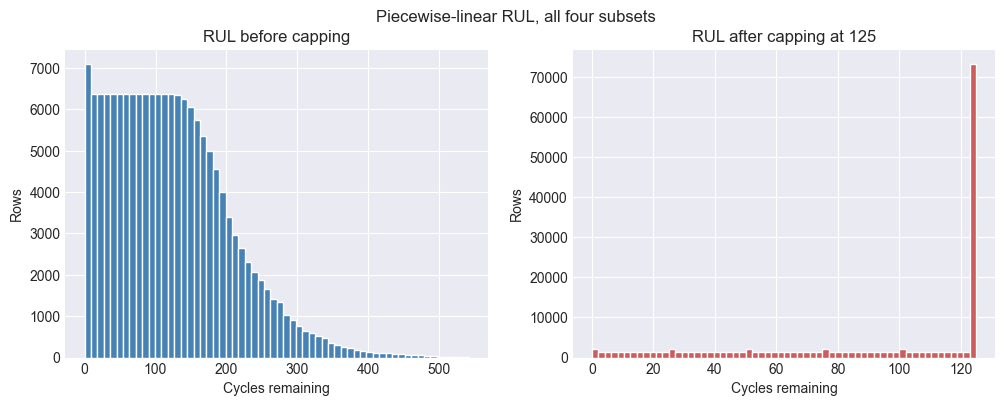

44.7% of training rows sit at the cap, which is the flat region the model no longer has to fit


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
raw_rul = (train.groupby('unit_uid').cycle.transform('max') - train.cycle)
axes[0].hist(raw_rul, bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('RUL before capping')
axes[1].hist(train.RUL, bins=60, color='indianred', edgecolor='white')
axes[1].set_title(f'RUL after capping at {RUL_CAP}')
for ax in axes:
    ax.set_xlabel('Cycles remaining')
    ax.set_ylabel('Rows')
fig.suptitle('Piecewise-linear RUL, all four subsets')
save_figure(fig, 'cmapss_preprocessing_rul_distribution', subfolder=ASSETS)
plt.show()

capped = float((train.RUL == RUL_CAP).mean())
print(f'{capped:.1%} of training rows sit at the cap, which is the flat region '
      f'the model no longer has to fit')

## 5. Operating regimes

Same key as the EDA notebook: the rounded triple of operating settings. It is
recomputed here rather than carried over, so this notebook runs on its own.

In [6]:
def regime_key(frame):
    return (frame.os_1.round(0).astype(int).astype(str) + '_'
            + frame.os_2.round(0).astype(int).astype(str) + '_'
            + frame.os_3.round(0).astype(int).astype(str))


train['regime'] = regime_key(train)
test['regime'] = regime_key(test)
regimes = sorted(train.regime.unique())

unseen = set(test.regime.unique()) - set(regimes)
assert not unseen, f'test contains regimes absent from train: {unseen}'

print(f'{len(regimes)} regimes: {regimes}')
print('every test regime is present in train')

6 regimes: ['0_0_100', '10_0_100', '20_1_100', '25_1_60', '35_1_100', '42_1_100']


every test regime is present in train


## 6. Which sensors carry nothing

Measured, not listed. A sensor is dropped only if its standard deviation is zero
inside **every** regime, which means it re-encodes the regime and nothing else.
The FD001 rule is printed beside it for comparison.

In [7]:
within_regime_std = train.groupby('regime')[SENSORS].std().max()
drop_sensors = [s for s in SENSORS if within_regime_std[s] < 1e-9]
keep_sensors = [s for s in SENSORS if s not in drop_sensors]

fd001 = train[train.dataset == 'FD001']
fd001_flat = [s for s in SENSORS if fd001[s].var() < 0.01]

print('dropped, zero variance in every regime :', drop_sensors)
print('kept                                   :', len(keep_sensors), 'sensors')
print()
print('the FD001 threshold rule would drop    :', fd001_flat)
print('kept here but dropped by that rule     :',
      sorted(set(fd001_flat) - set(drop_sensors)))

dropped, zero variance in every regime : ['s1', 's5', 's18', 's19']
kept                                   : 17 sensors

the FD001 threshold rule would drop    : ['s1', 's5', 's6', 's8', 's10', 's13', 's15', 's16', 's18', 's19']
kept here but dropped by that rule     : ['s10', 's13', 's15', 's16', 's6', 's8']


## 7. Standardisation, one scaler per regime

Fitted on training rows only and applied to test, so no test statistic leaks into
the model. A single global scaler would centre a sensor between its regime
levels, which turns a step change into apparent degradation.

In [8]:
before = train.loc[train.dataset == 'FD002', ['regime', 's11']].copy()

train[keep_sensors] = train[keep_sensors].astype('float64')
test[keep_sensors] = test[keep_sensors].astype('float64')

scalers = {}
for r in regimes:
    m_tr = train.regime == r
    scaler = StandardScaler()
    train.loc[m_tr, keep_sensors] = scaler.fit_transform(train.loc[m_tr, keep_sensors])
    m_te = test.regime == r
    if m_te.any():
        test.loc[m_te, keep_sensors] = scaler.transform(test.loc[m_te, keep_sensors])
    scalers[r] = scaler

after = train.loc[train.dataset == 'FD002', ['regime', 's11']]
print('s11 in FD002, mean per regime')
print(pd.DataFrame({'before': before.groupby('regime').s11.mean().round(2),
                    'after': after.groupby('regime').s11.mean().round(6)}).to_string())

s11 in FD002, mean per regime
          before     after
regime                    
0_0_100    47.54  0.223549
10_0_100   45.49  0.214464
20_1_100   44.45  0.211192
25_1_60    36.80  0.259501
35_1_100   41.98  0.215895
42_1_100   42.15  0.218812


  ✓ Saved → assets\timeseries\cmapss_preprocessing_regime_scaling.png


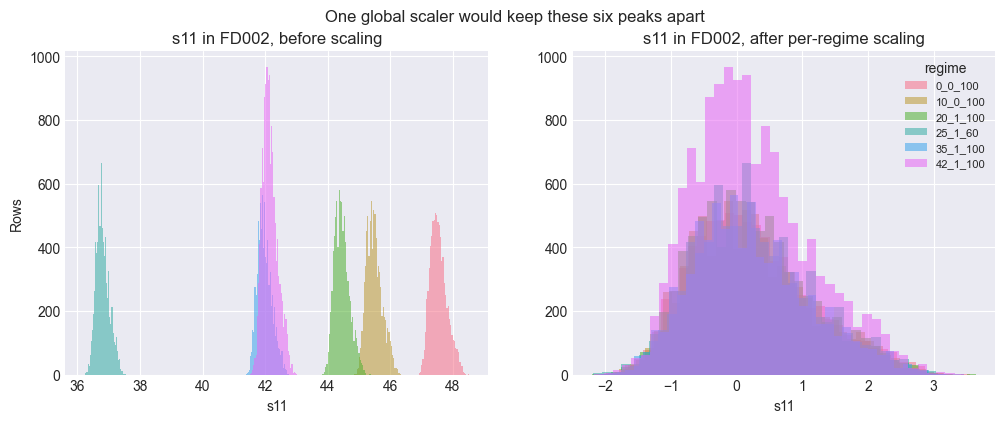

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, frame, title in [(axes[0], before, 'before scaling'),
                         (axes[1], after, 'after per-regime scaling')]:
    for r in regimes:
        values = frame.loc[frame.regime == r, 's11']
        if len(values):
            ax.hist(values, bins=40, alpha=0.55, label=r)
    ax.set_title(f's11 in FD002, {title}')
    ax.set_xlabel('s11')
axes[0].set_ylabel('Rows')
axes[1].legend(fontsize=8, title='regime')
fig.suptitle('One global scaler would keep these six peaks apart')
save_figure(fig, 'cmapss_preprocessing_regime_scaling', subfolder=ASSETS)
plt.show()

## 8. Temporal features

This is what separates the module from tabular regression. Without them a row is
one snapshot and the model leans on the raw cycle counter as its only proxy for
elapsed time, which is fragile: a real fleet resets that counter after an
overhaul.

Three blocks per kept sensor, all computed inside one engine's own history and
using only past and current cycles, so nothing leaks backwards:

- **rolling mean** over the window: the current level, with the noise smoothed;
- **rolling std** over the window: volatility, which rises as failure approaches;
- **drift**: the distance from the engine's own first cycles, which removes
  unit-to-unit variation between engines that were never identical.

In [10]:
temporal_cols = []
for frame in (train, test):
    frame.sort_values(['unit_uid', 'cycle'], inplace=True)
    grouped = frame.groupby('unit_uid', sort=False)[keep_sensors]

    roll_mean = grouped.rolling(WINDOW, min_periods=1).mean().reset_index(level=0, drop=True)
    roll_std = grouped.rolling(WINDOW, min_periods=1).std().reset_index(level=0, drop=True).fillna(0.0)
    baseline = grouped.transform(lambda s: s.iloc[:WINDOW].mean())

    for label, block in [('mean', roll_mean),
                         ('std', roll_std),
                         ('drift', frame[keep_sensors] - baseline)]:
        block = block.add_suffix(f'_{label}{WINDOW}')
        frame[block.columns] = block
        if not any(c.endswith(f'_{label}{WINDOW}') for c in temporal_cols):
            temporal_cols.extend(block.columns.tolist())

regime_code = {r: i for i, r in enumerate(regimes)}
for frame in (train, test):
    frame['regime_code'] = frame.regime.map(regime_code)

feature_cols = keep_sensors + ['cycle', 'regime_code'] + temporal_cols
print(f'{len(keep_sensors)} sensors + cycle + regime_code + '
      f'{len(temporal_cols)} temporal = {len(feature_cols)} features')
print(f'train matrix {len(train):,} x {len(feature_cols)}')

17 sensors + cycle + regime_code + 51 temporal = 70 features
train matrix 160,359 x 70


## 9. What one engine's new features look like

  ✓ Saved → assets\timeseries\cmapss_preprocessing_temporal_features.png


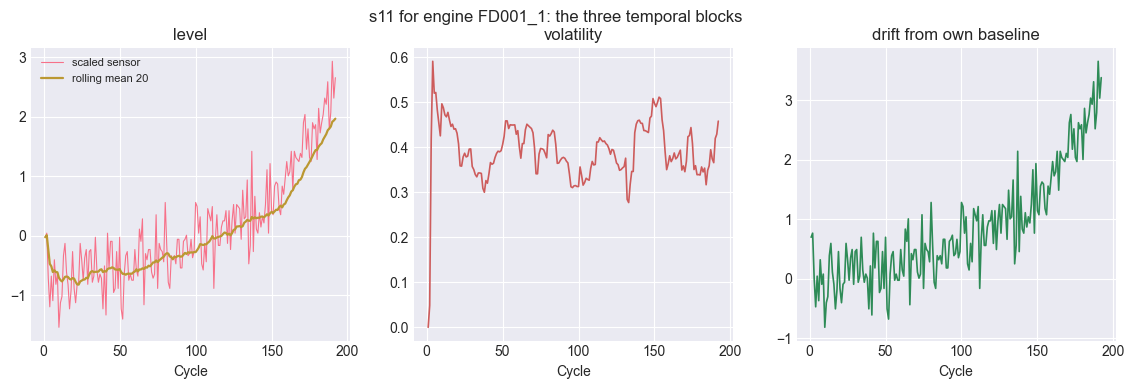

In [11]:
unit = 'FD001_1'
part = train[train.unit_uid == unit]
sensor = 's11'

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
axes[0].plot(part.cycle, part[sensor], linewidth=0.8, label='scaled sensor')
axes[0].plot(part.cycle, part[f'{sensor}_mean{WINDOW}'], linewidth=1.6, label=f'rolling mean {WINDOW}')
axes[0].set_title('level')
axes[0].legend(fontsize=8)
axes[1].plot(part.cycle, part[f'{sensor}_std{WINDOW}'], linewidth=1.2, color='indianred')
axes[1].set_title('volatility')
axes[2].plot(part.cycle, part[f'{sensor}_drift{WINDOW}'], linewidth=1.2, color='seagreen')
axes[2].set_title('drift from own baseline')
for ax in axes:
    ax.set_xlabel('Cycle')
fig.suptitle(f'{sensor} for engine {unit}: the three temporal blocks')
save_figure(fig, 'cmapss_preprocessing_temporal_features', subfolder=ASSETS)
plt.show()

## 10. Does this agree with the deployed pipeline

The deployed model was trained by `cmapss_full_fleet.py`, which saved its own
preprocessing artifact. Nothing above was imported from it. If the two disagree
about which sensors were kept, which regimes exist or what the feature columns
are, the difference is printed here rather than discovered later.

In [12]:
shipped_path = PROC_DIR / 'preprocessing_full_fleet.pkl'
if shipped_path.exists():
    shipped = joblib.load(shipped_path)
    checks = [
        ('kept sensors', keep_sensors, shipped['keep_sensors']),
        ('regimes', regimes, sorted(shipped['regimes'])),
        ('feature columns', feature_cols, shipped['feature_cols']),
    ]
    for label, mine, theirs in checks:
        same = list(mine) == list(theirs)
        print(f'{label:<16} {"match" if same else "DIFFER"}  '
              f'({len(mine)} here, {len(theirs)} deployed)')
        if not same:
            print('   only here    :', sorted(set(mine) - set(theirs))[:10])
            print('   only deployed:', sorted(set(theirs) - set(mine))[:10])
    print(f'RUL cap          {"match" if shipped["rul_cap"] == RUL_CAP else "DIFFER"}')
else:
    print('no deployed artifact to compare against at', shipped_path)

kept sensors     match  (17 here, 17 deployed)
regimes          match  (6 here, 6 deployed)
feature columns  match  (70 here, 70 deployed)
RUL cap          match


## 11. Save the processed fleet

In [13]:
joblib.dump({'scalers': scalers, 'regimes': regimes, 'keep_sensors': keep_sensors,
             'feature_cols': feature_cols, 'rul_cap': RUL_CAP},
            PROC_DIR / 'preprocessing_full_fleet.pkl')
train.to_csv(PROC_DIR / 'train_full_fleet_processed.csv', index=False)
test.to_csv(PROC_DIR / 'test_full_fleet_processed.csv', index=False)

for name in ['preprocessing_full_fleet.pkl', 'train_full_fleet_processed.csv',
             'test_full_fleet_processed.csv']:
    size = (PROC_DIR / name).stat().st_size / 1e6
    print(f'  {name:<36} {size:>8.1f} MB')

  preprocessing_full_fleet.pkl              0.0 MB
  train_full_fleet_processed.csv          225.3 MB
  test_full_fleet_processed.csv           148.7 MB


## 12. Summary

| Step | Decision | Why |
|---|---|---|
| Scope | All four subsets, 160,359 training rows | The deployed model serves a mixed fleet, so it is trained on one |
| Target | RUL capped at 125 cycles | The flat region before degradation begins carries no signal to fit |
| Sensors | Four dropped, seventeen kept | Only s1, s5, s18 and s19 have zero variance inside every regime |
| Scaling | One StandardScaler per regime, fitted on train | A global scaler turns a regime step change into apparent degradation |
| Features | 17 sensors + cycle + regime code + 51 temporal = 70 | A row must see its own recent history, not one snapshot |

**Next step:** `03_cmapss_modeling.ipynb` - a linear baseline, the XGBoost model,
the benchmark task at the last cycle of each engine, and a comparison against the
metrics the deployed model recorded.